In [ ]:
!pip install langchain-ollama

In [ ]:
import os
# for unstructuredpdfloader, poppler has to be install and path set or add environment variable for the session before we run program.

poppler_path = r"C:\Program Files\poppler\poppler-24.07.0\Library\bin"  # Adjust this path
os.environ["PATH"] += os.pathsep + poppler_path

In [ ]:
from langchain_community.document_loaders import PyPDFLoader
import os
from langchain_community.document_loaders import UnstructuredPDFLoader
from langchain_community.document_loaders import PyMuPDFLoader

def read_pdf_as_unstructured(pdf_path: str,current_dir: bool = True):
    if current_dir:
        dir_path = os.path.dirname(os.getcwd())
        file_path = os.path.join(dir_path,pdf_path)
    else:
        file_path = pdf_path
    print(f"Reading file from path: {file_path}")
    # Initialize the loader with the path to your PDF file
    
    loader = PyPDFLoader(file_path)
    documents = loader.load()
    
    # loader = UnstructuredPDFLoader(file_path)
    # documents = loader.load()
    
    # loader = PyMuPDFLoader(file_path)
    # documents = loader.load()
    
    print(f"File has been split into no of documents:{len(documents)}")
    return documents

In [ ]:
pdf_path = "69802168-Air-India-Ahmedabad-Crash-AAIB-preliminary-report.pdf"
docs = read_pdf_as_unstructured(pdf_path)

In [ ]:
docs[2].page_content

In [ ]:
# Now you can use `docs` with a LangChain chain or retrieval system
print(f"Number of documents loaded: {len(docs)}")
print(f"Content of the first document: \n{docs[4].page_content}")

In [186]:
from langchain_text_splitters import CharacterTextSplitter, RecursiveCharacterTextSplitter, MarkdownHeaderTextSplitter
from langchain_core.documents import Document
from typing import List, Tuple

def split_docs(docs: List[Document],
               markdown_separators: List[Tuple[str,str]], 
               text_separators: List[str]) -> List[Document]:
    
    # Optionally, you can split the documents for processing by a language model
    
    # Initialize markdown splitter
    markdown_splitter = MarkdownHeaderTextSplitter(
        headers_to_split_on=markdown_separators,
        strip_headers=False
    )

    # Initialize recursive character splitter as backup
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,
        chunk_overlap=50,
        length_function=len,
        separators=text_separators
    )

    all_chunks = []
    
    for doc in docs:
        try:
            # Try markdown splitting first
            md_chunks = markdown_splitter.split_text(doc.page_content)
            if md_chunks and len(md_chunks)>1:
                print(f"Markdown splitter chunks:{len(md_chunks)}")
                # Convert to Document objects
                for chunk in md_chunks:
                    chunk.metadata=doc.metadata
                    chunks = text_splitter.split_documents([chunk])
                    all_chunks.extend(chunks)
            else:
                print(f"No Markdown splitter chunks, so proceeding with text splitter")
                # Fallback to recursive character splitting
                chunks = text_splitter.split_documents([doc])
                all_chunks.extend(chunks)
            print(f"total no of chunks after split:{len(all_chunks)}")
            
        except Exception as e:
            print(f"⚠️ Markdown splitting failed for a document: {e}")
            print(f"No Markdown splitter chunks, so proceeding with text splitter")
            # Fallback to recursive character splitting
            chunks = text_splitter.split_documents([doc])
            all_chunks.extend(chunks)
            print(f"total no of chunks after split:{len(all_chunks)}")
    return all_chunks
    

In [ ]:
markdown_separators = [
        ("#", "Header 1"),
        ("##", "Header 2"),
        ("###", "Header 3"),
        ("####", "Header 4"),
    ]
    
text_separators =[" \n \n \n \n"," \n \n \n"," \n \n"," \n"]
    
splitted_docs = split_docs(docs,markdown_separators,text_separators)
# test_docs = split_docs([docs[4]],markdown_separators,text_separators)

In [188]:
# Not working as expected
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langchain.vectorstores import Chroma

from chromadb import PersistentClient

# Delete collection if exists
def reset_collection(client,persist_dir, collection_name):
    existing = [c.name for c in client.list_collections()]
    if collection_name in existing:
        print(f"🗑️ Deleting existing collection: {collection_name}")
        client.delete_collection(name=collection_name)


# Create new collection
def create_chroma(docs,  persist_dir, collection_name):
    embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
    vectordb = Chroma.from_documents(
        documents=docs,
        embedding=embeddings,
        persist_directory=persist_dir,
        collection_name=collection_name
    )
    vectordb.persist()
    return vectordb

def create_vector_store(docs,persist_dir, collection_name, reset=True):
    
    client = PersistentClient(path=persist_dir)
    
    if reset:
        reset_collection(client,persist_dir, collection_name)

    print(f"Create new vector store at:{persist_dir}, collection named:{collection_name}")
    
    db_store = create_chroma(docs,  persist_dir, collection_name)
    return db_store

def load_vector_store(persist_dir, collection_name):
    
    client = PersistentClient(path=persist_dir)
    embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
    
    # Load the collection from the persistent client
    vector_store = Chroma(
        client=client,
        collection_name=collection_name,
        embedding_function=embeddings
    )
    print(f"Vector store loaded successfully from {persist_directory} with collection name {collection_name}")
    return vector_store
 
    

In [189]:
persist_directory = "./chroma_vectordb/"
collection_name="airindia_crash_2025"

vector_store = create_vector_store(splitted_docs,persist_directory,collection_name)

🗑️ Deleting existing collection: airindia_crash_2025
Create new vector store at:./chroma_vectordb/, collection named:airindia_crash_2025


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


In [ ]:
vector_db = load_vector_store(persist_directory,collection_name)

In [ ]:
def get_query_context(query,top_k=3): 
  result = vector_db.similarity_search(query,top_k)
  return result 

def get_query_context_by_embeddings(query,top_k=3): 
  embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
  embedding_query = embeddings.embed_query(query)

  result = vector_db.similarity_search_by_vector(embedding_query,top_k)
  return result

In [ ]:
context = get_query_context("which city and country the accident happened?",1)
context

In [153]:
from langchain_community.document_loaders import WebBaseLoader
url = "https://spark.apache.org/docs/latest/sql-performance-tuning.html"
url_docs = WebBaseLoader(url).load()

In [ ]:
url_docs

In [190]:
markdown_separators = [
        ("#", "Header 1"),
        ("##", "Header 2"),
        ("###", "Header 3"),
        ("####", "Header 4"),
    ]
    
text_separators =[" \n \n \n"," \n \n"," \n"]
    
url_splitted_docs = split_docs(url_docs,markdown_separators,text_separators)

No Markdown splitter chunks, so proceeding with text splitter
total no of chunks after split:43


In [192]:
persist_directory = "./chroma_vectordb/"
collection_name="spark_performance_doc"

vector_store = create_vector_store(url_splitted_docs,persist_directory,collection_name)

Create new vector store at:./chroma_vectordb/, collection named:spark_performance_doc


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


In [197]:
election_pdf_path = "Analysis_of_Vote_Share_and_Margin_of_Victory_of_Winners_Andhra_Pradesh_Assembly_2024_Finalver_English.pdf"
election_docs = read_pdf_as_unstructured(election_pdf_path)

Reading file from path: C:\Users\Asus\PycharmProjects\GenAIPractise\Analysis_of_Vote_Share_and_Margin_of_Victory_of_Winners_Andhra_Pradesh_Assembly_2024_Finalver_English.pdf
File has been split into no of documents:65


In [ ]:
election_splitted_docs = split_docs(election_docs,markdown_separators,text_separators)

In [200]:
persist_directory = "./chroma_vectordb/"
collection_name="andhrapradesh_election_results"

vector_store = create_vector_store(election_splitted_docs,persist_directory,collection_name)

Create new vector store at:./chroma_vectordb/, collection named:andhrapradesh_election_results


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


In [1]:
persist_directory = "./chroma_vectordb/"
from langchain_community.tools import DuckDuckGoSearchRun



def load_vector_dbs():   
    vector_dbs = {"andhrapradesh_election_results":load_vector_store(persist_directory,"andhrapradesh_election_results"),
              "spark_performance_doc":load_vector_store(persist_directory,"spark_performance_doc"),
              "airindia_crash_2025":load_vector_store(persist_directory,"airindia_crash_2025")}
    return vector_dbs
    
    
def get_election_query_context(query, top_k=1):
    """
    This function is used retrieve the context related election data, like constituency, parties contested, majority, winner, no of votes, etc.
    """
    collection_name = "andhrapradesh_election_results"
    vector_db = vector_dbs[collection_name]
    result = vector_db.similarity_search(query,top_k)
    return result 

def get_performance_query_context(query, top_k=1):
    """
    This function is used retrieve the context related Spark 4.o performance tuning.
    """
    collection_name = "spark_performance_doc"
    vector_db = vector_dbs[collection_name]
    result = vector_db.similarity_search(query,top_k)
    return result   

def get_airindia_crash_query_context(query, top_k=1):
    """
    This function is used retrieve the context related Air india crash incident preliminary report, like when and where incident happen, date, time, no of fatalities, injured, etc.
    """
    collection_name = "airindia_crash_2025"
    vector_db = vector_dbs[collection_name]
    result = vector_db.similarity_search(query,top_k)
    return result     
    
def duckduckgo_search(query):
    """
    This function is used to search web using duckduckgo.
    """
    ducksearch = DuckDuckGoSearchRun()
    return ducksearch.invoke(query)

    

In [277]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode, tools_condition
from typing import List, TypedDict, Annotated, 
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage
import operator

# Define your tools first (before using them)
tools = [get_election_query_context, get_performance_query_context, get_airindia_crash_query_context,duckduckgo_search]

# Updated State class
class State(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]  # Required for LangGraph
    question: str
    context: List[str]  # Assuming Document has text content
    answer: str

# Initialize LLM with tools
llm = ChatOpenAI(model="gpt-4o-mini", max_tokens=150)  # Fixed typo: "minit" -> "mini"
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    """Main chatbot function that decides whether to use tools or generate final answer"""
    
    # Get the last message or create one from question
    if state.get("messages"):
        last_message = state["messages"][-1]
        question = last_message.content if hasattr(last_message, 'content') else state.get("question", "")
    else:
        question = state.get("question", "")
    
    # Create a proper message format for the LLM
    messages = [
        {"role": "user", "content": f"Question: {question}\nContext: {state.get('context', 'No context available')}"}
    ]
    
    # Get response from LLM
    response = llm_with_tools.invoke(messages)
    
    # Update messages list
    current_messages = state.get("messages", [])
    if not current_messages:  # Add user message if not exists
        current_messages.append(HumanMessage(content=question))
    current_messages.append(response)
    
    return {
        "messages": current_messages,
        "question": question,
        "context": state.get("context", []),
        "answer": response.content if hasattr(response, 'content') else str(response)
    }

def should_continue(state: State):
    """Determine if we should continue to tools or end"""
    messages = state.get("messages", [])
    if not messages:
        return END
    
    last_message = messages[-1]
    # Check if the last message has tool calls
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "tools"
    return END

# Create the graph
graph_builder = StateGraph(State)

# Define Nodes
graph_builder.add_node("assistant", chatbot)
graph_builder.add_node("tools", ToolNode(tools))

# Define edges - Fixed order and logic
graph_builder.add_edge(START, "assistant")
graph_builder.add_conditional_edges(
    "assistant", 
    should_continue,  # Custom condition function
    {
        "tools": "tools",
        END: END
    }
)
graph_builder.add_edge("tools", "assistant")  # Tools should go back to assistant, not END

# Compile the graph
graph = graph_builder.compile()

# Example usage function
def run_query(question: str):
    """Run a query through the graph"""
    initial_state = {
        "question": question,
        "messages": [],
        "context": [],
        "answer": ""
    }
    
    result = graph.invoke(initial_state)
    return result


    

In [ ]:
# Example usage:
result = run_query("when and where was air india incident took place?")
print(result["answer"])

In [279]:
result

{'messages': [HumanMessage(content='What happened in the recent elections?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_pOJx2hS8f9ApFhCKnnc1MDPi', 'function': {'arguments': '{"query":"recent elections"}', 'name': 'get_election_query_context'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 228, 'total_tokens': 246, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-C5w8FUkcpZDoeOHZh9KvCPzNYU9DL', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--e9ba3e5c-eb71-436a-8312-85e8c45d7d78-0', tool_calls=[{'name': 'get_election_query_context', 'args': {'query': 'recent ele

In [249]:
from langchain_openai import  ChatOpenAI
from langchain.prompts import ChatPromptTemplate
from typing import List, TypedDict

from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END


prompt_msg = ChatPromptTemplate.from_template("""Anwser the following question using given context.

Context: {context}

Question: {question}

Answer: 
""")


llm = ChatOpenAI(model="gpt-4o-minit",max_tokens=150)


    
class State(TypedDict):
    question: str
    context: List[Document]
    answer: str


def retriever(state: State):
    
    print(f"retriever input state:{state}")
    
    if "performance" in state["question"]:
        
        print(f"""invoking performance retriever and Question:{state["question"]}""")
        context = get_performance_query_context(state["question"],1)
        
    elif "election" in state["question"] :
        
        print(f"""invoking election retriever and Question:{state["question"]}""")
        context = get_election_query_context(state["question"],1)
        
    else:
        
        print(f"""invoking other retriever and Question:{state["question"]}""")
        context = get_airindia_crash_query_context(state["question"],1)
        
    return {"context": context}

def generate(state: State):
    
    docs_content = "\n".join([doc.page_content for doc in state["context"]])
    
    prompt = prompt_msg.invoke({"question":state["question"],
                                "context":docs_content})
    print(f"Generated prompt:{prompt}")
    
    answer = llm.invoke(prompt)
    print(f"Response: {response}")
    
    return {"answer":answer}

graph_builder = StateGraph(State).add_sequence([retriever,generate])
graph_builder.add_edge(START,"retriever")
graph_builder.add_edge("retriever","generate")
graph_builder.add_edge("generate", END)

graph = graph_builder.compile()



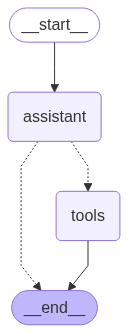

In [269]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
response = graph.invoke({"question":"how many of them died in an air india accident?"})
print(response)

In [248]:
print(response["answer"].content)

In the accident, a total of 12 crew members, 229 passengers, and 19 others died. Therefore, the total number of fatalities is 12 + 229 + 19 = 260.
